# Exploratory Data Analysis: Last Mile Delivery Optimization

In this notebook, we analyze the 500,000-row `processed_sample.parquet` dataframe. We simulate these taxi trips as last-mile delivery orders.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot style
plt.style.use('dark_background')
sns.set_theme(style="darkgrid", rc={"axes.facecolor": "#1e1e1e", "figure.facecolor": "#121212"})

DATA_DIR = Path("../data")
df = pd.read_parquet(DATA_DIR / "processed_sample.parquet")
print(f"Loaded {len(df):,} rows.")
df.head(3)

Loaded 500,000 rows.


,pickup_dt,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,trip_distance,haversine_km,trip_duration_mins,speed_mph,hour_of_day,day_of_week,is_weekend,month,traffic_level,passenger_count,fare_amount
0,2015-01-15 19:05:39,40.750111,-73.993896,40.750618,-73.974785,1.59,1.610893,18.050000,5.285319,19,3,0,1,Heavy,1,12.0
1,2015-01-10 20:33:38,40.724243,-74.001648,40.759109,-73.994415,3.30,3.924552,19.833333,9.983193,20,5,1,1,Heavy,1,14.5
2,2015-01-10 20:33:38,40.802788,-73.963341,40.824413,-73.951820,1.80,2.592739,10.050000,10.746269,20,5,1,1,Moderate,1,9.5


## 1. Delivery Duration vs Distance
Is there a linear relationship between the straight-line distance and the actual trip duration?

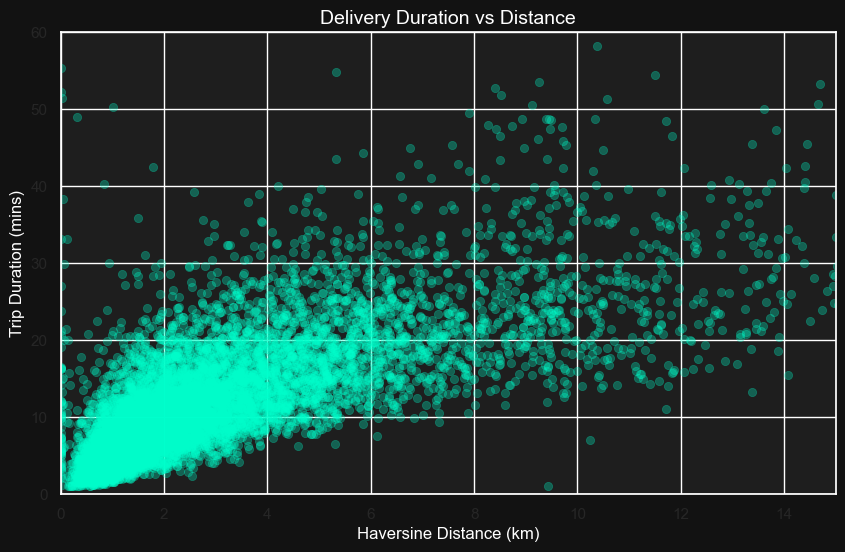

In [2]:
plt.figure(figsize=(10, 6))
# Sample further for plotting speed
sample_df = df.sample(10000, random_state=42)
sns.scatterplot(data=sample_df, x="haversine_km", y="trip_duration_mins", 
                alpha=0.3, color="#00ffcc", edgecolor=None)
plt.title("Delivery Duration vs Distance", fontsize=14, color="white")
plt.xlabel("Haversine Distance (km)", color="white")
plt.ylabel("Trip Duration (mins)", color="white")
plt.xlim(0, 15)
plt.ylim(0, 60)
plt.show()

## 2. Peak Hours Analysis
When are deliveries taking the longest, and when is traffic heaviest?

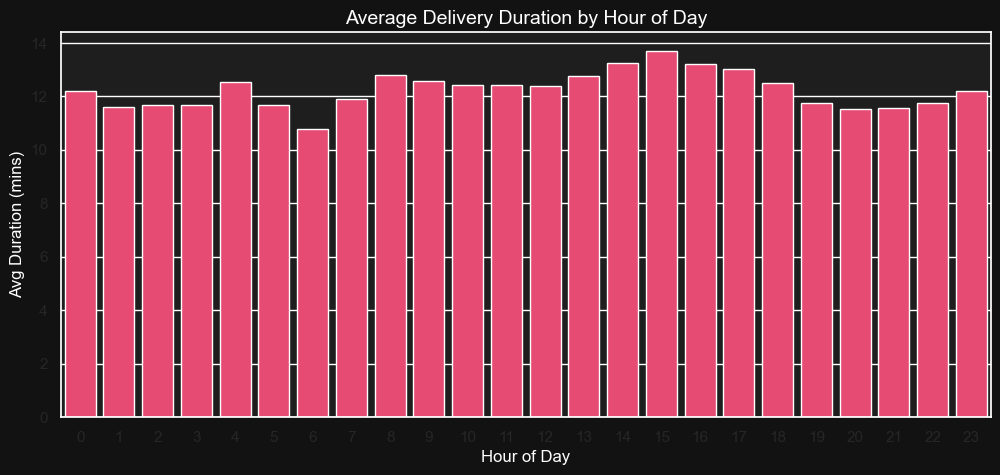

In [3]:
plt.figure(figsize=(12, 5))
hourly_duration = df.groupby("hour_of_day")["trip_duration_mins"].mean().reset_index()
sns.barplot(data=hourly_duration, x="hour_of_day", y="trip_duration_mins", color="#ff3366")
plt.title("Average Delivery Duration by Hour of Day", fontsize=14, color="white")
plt.xlabel("Hour of Day", color="white")
plt.ylabel("Avg Duration (mins)", color="white")
plt.show()

## 3. Heatmap: Hour vs Day of Week
Let's see average speeds to identify the 'busiest' times for couriers.

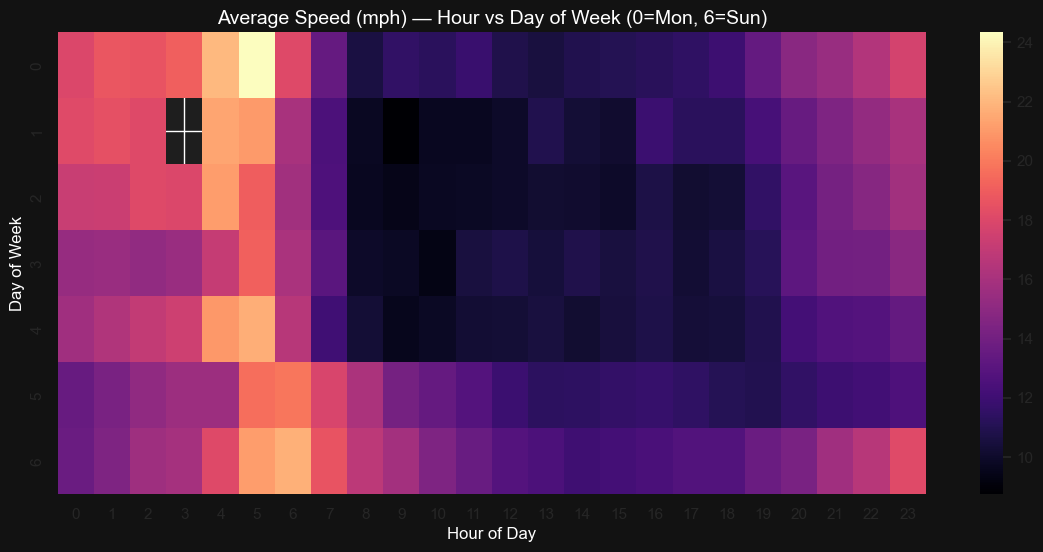

In [4]:
pivot_speed = df.pivot_table(index="day_of_week", columns="hour_of_day", values="speed_mph", aggfunc="mean")

plt.figure(figsize=(14, 6))
sns.heatmap(pivot_speed, cmap="magma", annot=False)
plt.title("Average Speed (mph) — Hour vs Day of Week (0=Mon, 6=Sun)", fontsize=14, color="white")
plt.xlabel("Hour of Day", color="white")
plt.ylabel("Day of Week", color="white")
plt.show()

## 4. Correlation Matrix
Which engineered features correlate best with our target (`trip_duration_mins`)?

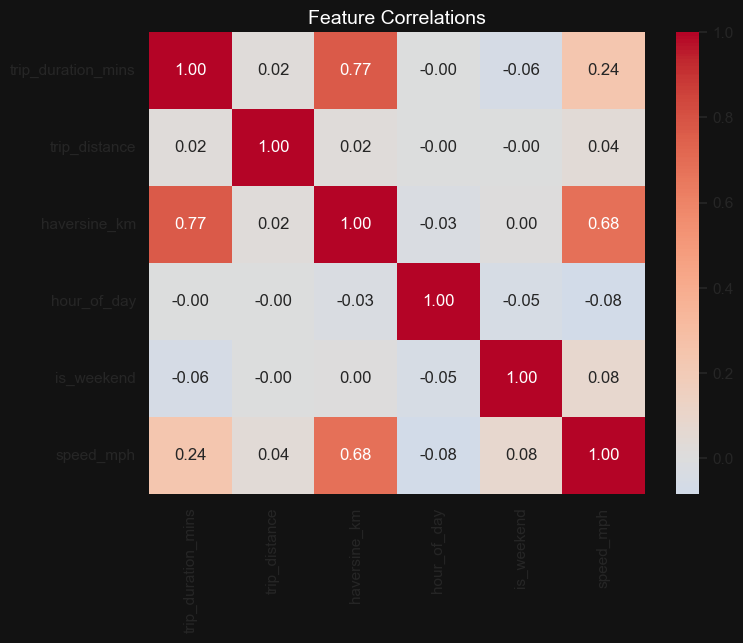

In [5]:
cols = ["trip_duration_mins", "trip_distance", "haversine_km", "hour_of_day", "is_weekend", "speed_mph"]
corr = df[cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Feature Correlations", fontsize=14, color="white")
plt.show()